This notebook trains a YOLOv8n face detector and evaluates a strategic hat occlusion attack.

In [1]:
!pip install kaggle

Downloading Dataset

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fareselmenshawii/face-detection-dataset")

print("Path to dataset files:", path)

100%|██████████| 4.43G/4.43G [00:39<00:00, 121MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/fareselmenshawii/face-detection-dataset/versions/3


In [3]:
import os

print(os.listdir(path))

for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f"{indent}{os.path.basename(root)}/")

['images', 'labels', 'labels2']
3/
    images/
        val/
        train/
    labels/
        val/
        train/
    labels2/


In [4]:
import cv2
import matplotlib.pyplot as plt

img_path = "/root/.cache/kagglehub/datasets/fareselmenshawii/face-detection-dataset/versions/3/images/train/d3f35accd0f22f28.jpg"
label_path = img_path.replace("images", "labels").replace(".jpg", ".txt")

The next cells generate face_data.yaml and fine-tune the model on train and validation splits.

In [5]:
!pip install ultralytics -q

from ultralytics import YOLO

model = YOLO('yolov8n.pt')

print("Model loaded and ready for training!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 36.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Model loaded and ready for training!


In [6]:
import yaml

data_config = {
    'path': path,
    'train': 'images/train',
    'val': 'images/val',
    'nc': 1,
    'names': ['face']
}

yaml_file_path = '/content/face_data.yaml'
with open(yaml_file_path, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print(f"YAML created at: {yaml_file_path}")
print("--- Path Verification ---")
print(f"Full Train Path: {os.path.join(path, 'images/train')}")
print(f"Exists? {os.path.exists(os.path.join(path, 'images/train'))}")

YAML created at: /content/face_data.yaml
--- Path Verification ---
Full Train Path: /root/.cache/kagglehub/datasets/fareselmenshawii/face-detection-dataset/versions/3/images/train
Exists? True


This block applies the hat image over face regions and computes recall before and after occlusion.

In [7]:
model = YOLO('yolov8n.pt')


model.train(
    data='/content/face_data.yaml',
    epochs=3,
    imgsz=640,
    batch=16,
    name='face_detection_colab'
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/face_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=face_detection_colab, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patie

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7cbeeb78b620>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [8]:
import glob
import os
import cv2
import numpy as np
import pandas as pd

num_test_images = 100
conf_threshold = 0.4
val_images_path = os.path.join(path, 'images/val')
hat_path = "/content/hat.png"

weight_files = glob.glob('/content/runs/detect/*/weights/best.pt')
model_path = max(weight_files, key=os.path.getctime) if weight_files else 'yolov8n.pt'
model = YOLO(model_path)

def apply_strategic_occlusion(img_path, hat_path):
    img = cv2.imread(img_path)
    hat = cv2.imread(hat_path, cv2.IMREAD_UNCHANGED)
    if img is None or hat is None: return None

    label_path = img_path.replace("images", "labels").replace(".jpg", ".txt").replace(".png", ".txt")
    if not os.path.exists(label_path): return img

    h, w, _ = img.shape
    with open(label_path, 'r') as f:
        for line in f.readlines():
            parts = list(map(float, line.split()))
            if len(parts) < 5: continue

            _, x_c, y_c, bw, bh = parts

            head_top_y = y_c - (bh * 0.9)
            hw = int(bw * w * 1.5)
            hh = int(hat.shape[0] * (hw / hat.shape[1]))
            resized_hat = cv2.resize(hat, (hw, hh))

            x1, y1 = int((x_c * w) - (hw / 2)), int((head_top_y * h) - (hh / 2))

            for i in range(hh):
                for j in range(hw):
                    if 0 <= y1 + i < h and 0 <= x1 + j < w:
                        if resized_hat.shape[2] == 4:
                            alpha = resized_hat[i, j, 3] / 255.0
                            img[y1+i, x1+j] = (1 - alpha) * img[y1+i, x1+j] + alpha * resized_hat[i, j, :3]
                        else:
                            img[y1+i, x1+j] = resized_hat[i, j]
    return img

results_data = []
val_files = [f for f in os.listdir(val_images_path) if f.endswith(('.jpg', '.png'))][:num_test_images]

for filename in val_files:
    img_p = os.path.join(val_images_path, filename)
    label_p = img_p.replace("images", "labels").replace(".jpg", ".txt").replace(".png", ".txt")

    if not os.path.exists(label_p): continue
    with open(label_p, 'r') as f:
        gt_count = len(f.readlines())

    res_orig = model.predict(img_p, conf=conf_threshold, verbose=False)
    tp_orig = len(res_orig[0].boxes)

    occ_img = apply_strategic_occlusion(img_p, hat_path)
    res_occ = model.predict(occ_img, conf=conf_threshold, verbose=False)
    tp_occ = len(res_occ[0].boxes)

    results_data.append({'gt': gt_count, 'orig': tp_orig, 'occ': tp_occ})

df = pd.DataFrame(results_data)
total_gt = df['gt'].sum()
rec_orig = df['orig'].sum() / total_gt
rec_occ = df['occ'].sum() / total_gt

print("\n" + "="*45)
print(f"STRATEGIC PLACEMENT REPORT (HAT)")
print("="*45)
print(f"Recall (Clean):         {rec_orig:.2%}")
print(f"Recall (Strategic):     {rec_occ:.2%}")
print(f"Total Recall Drop:      {rec_orig - rec_occ:.2%}")
print("="*45)


STRATEGIC PLACEMENT REPORT (HAT)
Recall (Clean):         76.65%
Recall (Strategic):     46.30%
Total Recall Drop:      30.35%


The remaining cells locate failed detections and display a side-by-side clean versus occluded example.

In [14]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
from ultralytics import YOLO

val_images_path = os.path.join(path, 'images/val')
hat_path = "/content/hat.png"

weight_files = glob.glob('/content/runs/detect/*/weights/best.pt')
model_path = max(weight_files, key=os.path.getctime) if weight_files else 'yolov8n.pt'
model = YOLO(model_path)

def apply_strategic_occlusion(img_path, hat_path):
    img = cv2.imread(img_path)
    hat = cv2.imread(hat_path, cv2.IMREAD_UNCHANGED)
    if img is None or hat is None: return None
    label_path = img_path.replace("images", "labels").replace(".jpg", ".txt").replace(".png", ".txt")
    if not os.path.exists(label_path): return img
    h, w, _ = img.shape
    with open(label_path, 'r') as f:
        for line in f.readlines():
            parts = list(map(float, line.split()))
            if len(parts) < 5: continue
            _, x_c, y_c, bw, bh = parts
            head_y_c = y_c - (bh * 1)
            hw = int(bw * w * 1.5)
            hh = int(hat.shape[0] * (hw / hat.shape[1]))
            resized_hat = cv2.resize(hat, (hw, hh))
            M = cv2.getRotationMatrix2D((hw//2, hh//2), 2, 1.0)
            resized_hat = cv2.warpAffine(resized_hat, M, (hw, hh), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=(0,0,0,0))
            x1, y1 = int((x_c * w) - (hw / 2)), int((head_y_c * h) - (hh / 2))
            for i in range(hh):
                for j in range(hw):
                    if 0 <= y1 + i < h and 0 <= x1 + j < w:
                        if resized_hat.shape[2] == 4:
                            alpha = resized_hat[i, j, 3] / 255.0
                            img[y1+i, x1+j] = (1 - alpha) * img[y1+i, x1+j] + alpha * resized_hat[i, j, :3]
                        else:
                            img[y1+i, x1+j] = resized_hat[i, j]
    return img

all_val_files = [f for f in os.listdir(val_images_path) if f.endswith(('.jpg', '.png'))][:100]
failed_cases = []

for filename in all_val_files:
    img_p = os.path.join(val_images_path, filename)
    orig_results = model.predict(img_p, conf=0.4, verbose=False)
    occ_img = apply_strategic_occlusion(img_p, hat_path)
    occ_results = model.predict(occ_img, conf=0.4, verbose=False)
    if len(orig_results[0].boxes) > 0 and len(occ_results[0].boxes) == 0:
        failed_cases.append(filename)

print(f"Found {len(failed_cases)} failed cases in the first 100 images.")

Found 17 failed cases in the first 100 images.


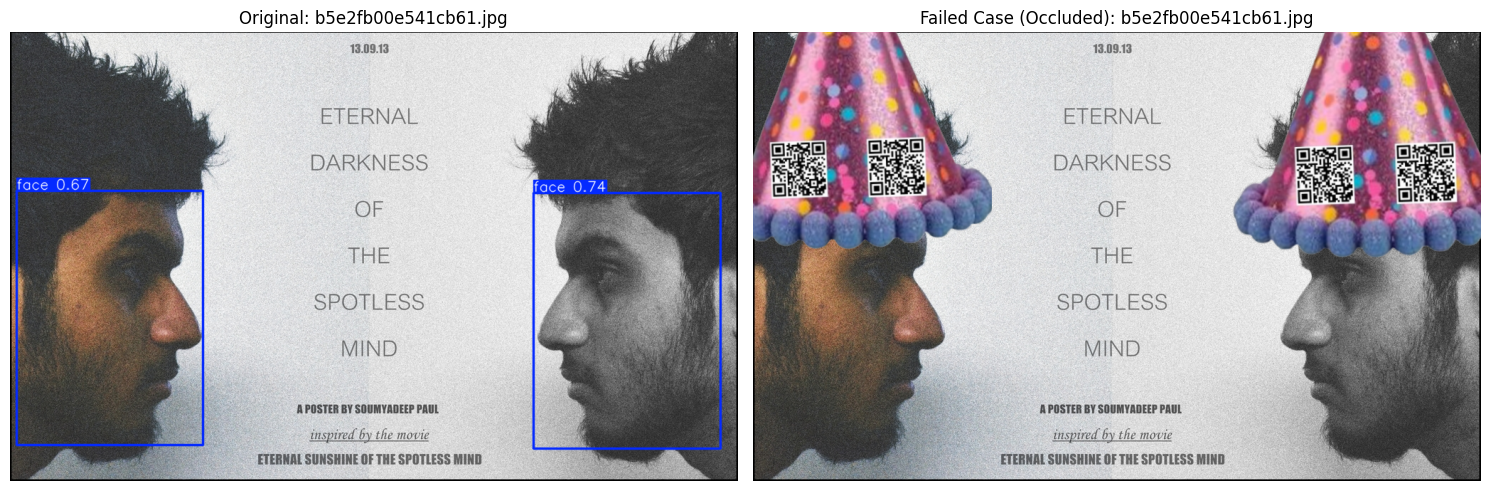

In [32]:
val_images_path = os.path.join(path, 'images/val')
hat_path = "/content/hat.png"

weight_files = glob.glob('/content/runs/detect/*/weights/best.pt')
model_path = max(weight_files, key=os.path.getctime) if weight_files else 'yolov8n.pt'
model = YOLO(model_path)
def apply_strategic_occlusion(img_path, hat_path):
    img = cv2.imread(img_path)
    hat = cv2.imread(hat_path, cv2.IMREAD_UNCHANGED)
    if img is None or hat is None: return None
    label_path = img_path.replace("images", "labels").replace(".jpg", ".txt").replace(".png", ".txt")
    if not os.path.exists(label_path): return img
    h, w, _ = img.shape
    with open(label_path, 'r') as f:
        for line in f.readlines():
            parts = list(map(float, line.split()))
            if len(parts) < 5: continue
            _, x_c, y_c, bw, bh = parts
            head_y_c = y_c - (bh * 1)
            hw = int(bw * w * 1.5)
            hh = int(hat.shape[0] * (hw / hat.shape[1]))
            resized_hat = cv2.resize(hat, (hw, hh))
            M = cv2.getRotationMatrix2D((hw//2, hh//2), 2, 1.0)
            resized_hat = cv2.warpAffine(resized_hat, M, (hw, hh), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=(0,0,0,0))
            x1, y1 = int((x_c * w) - (hw / 2)), int((head_y_c * h) - (hh / 2))
            for i in range(hh):
                for j in range(hw):
                    if 0 <= y1 + i < h and 0 <= x1 + j < w:
                        if resized_hat.shape[2] == 4:
                            alpha = resized_hat[i, j, 3] / 255.0
                            img[y1+i, x1+j] = (1 - alpha) * img[y1+i, x1+j] + alpha * resized_hat[i, j, :3]
                        else:
                            img[y1+i, x1+j] = resized_hat[i, j]
    return img

image_index = 5

if len(failed_cases) > 0:
    filename = failed_cases[image_index]
    img_p = os.path.join(val_images_path, filename)
    fig, axes = plt.subplots(1, 2, figsize=(15, 7))
    res_orig = model.predict(img_p, conf=0.4, verbose=False)[0].plot()
    res_orig = cv2.cvtColor(res_orig, cv2.COLOR_BGR2RGB)
    occ_img = apply_strategic_occlusion(img_p, hat_path)
    res_occ_plot = model.predict(occ_img, conf=0.4, verbose=False)[0].plot()
    res_occ_plot = cv2.cvtColor(res_occ_plot, cv2.COLOR_BGR2RGB)
    axes[0].imshow(res_orig)
    axes[0].set_title(f"Original: {filename}")
    axes[0].axis('off')
    axes[1].imshow(res_occ_plot)
    axes[1].set_title(f"Failed Case (Occluded): {filename}")
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No failed cases found in this subset.")